In [15]:
import numpy as np
import warnings
warnings.filterwarnings("ignore")
import wandb
import grid2op
from lightsim2grid import LightSimBackend
from gnn.obs_converter import collect_node_and_edge_features, collect_node_and_edge_features_separated
from gnn.torch_geometric_datasets import Grid2opGraphDatasetSoft, Grid2opGraphDatasetProcessed
from gnn.gnn_models import GAT
from torch_geometric.loader import DataLoader
import torch

from pathlib import Path
import os
import pickle
import  matplotlib.pyplot as plt
import h5py
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import torch

import torch.nn as nn
from sklearn.preprocessing import StandardScaler
import torch.nn.functional as F
from torch_geometric.nn import GATConv, global_mean_pool, global_max_pool, global_add_pool
from torch_geometric.data import Data
from grid2op.Observation import CompleteObservation

In [3]:
backend = LightSimBackend()
env_name = "l2rpn_icaps_2021_large_train"  # or any other...
env = grid2op.make(env_name, backend=backend, observation_class=CompleteObservation)
obs = env.reset()

### Extract Colnames

# Extract Dataset

#### Read the data

In [15]:
from pathlib import Path
import h5py
import numpy as np

def read_sample_h5_new(save_path: Path):
    
    results = []
    with h5py.File(save_path, "r") as f:
        for group_name in f.keys(): 
            group = f[group_name]
            results.append({
                "state": group["state"][:],
                "max_rhos": group["max_rhos"][:],  # Länge 2000
            })
    return results


In [16]:
root_dir = Path("./data/data_00/data_greedy")
h5_files = list(root_dir.glob("*.h5"))  

all_data = []

for h5_path in h5_files:
    chronic_data = read_sample_h5_new(h5_path)
    all_data.extend(chronic_data)   # an die große Liste anhängen

print(f"Anzahl H5-Dateien: {len(h5_files)}")
print(f"Anzahl Samples gesamt: {len(all_data)}")

data = all_data  


Anzahl H5-Dateien: 993
Anzahl Samples gesamt: 15675


## plot labels with different temprature

In [8]:
data[15]

{'state': array([2.012e+03, 2.000e+00, 3.000e+00, ..., 0.000e+00, 0.000e+00,
        0.000e+00], shape=(1513,), dtype=float32),
 'max_rhos': array([0.9955174, 1.0087732, 1.4592932, ..., 1.0304704, 0.9855242,
        1.0292616], shape=(2000,), dtype=float32)}

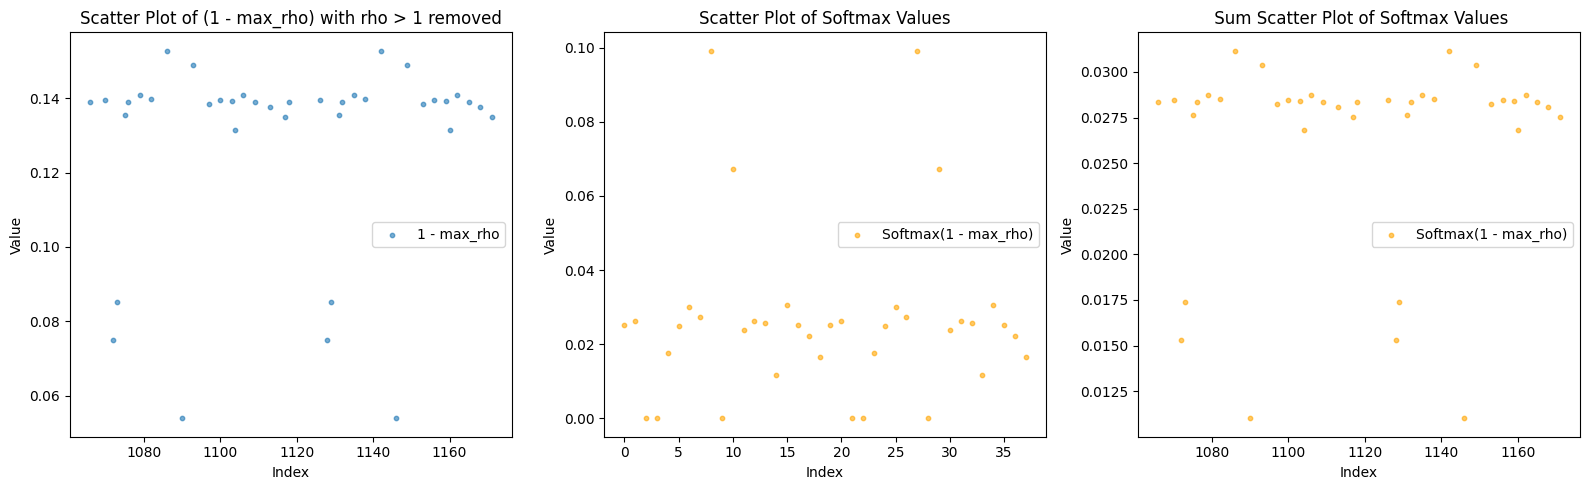

In [9]:
total_ids = 2000
i = 4
#i = np.random.randint(0, len(data))

max_rhos = data[i]["max_rhos"]              # shape (2000,)
refilled_values = np.array(max_rhos, dtype=float)
refilled_values[refilled_values >= 0.95] = np.inf
#clean_arr = refilled_values[~np.isinf(refilled_values).all(axis=1)]
# remove index -1 because donothing is already present in index 31
#refilled_values = refilled_values[1:]


# First plot: (1 - refilled_values)
plt.figure(figsize=(16, 5))
plt.subplot(1, 3, 1)
plt.scatter(x=np.arange(total_ids), y=(1 - refilled_values), s=10, alpha=0.6, label="1 - max_rho")
plt.title("Scatter Plot of (1 - max_rho) with rho > 1 removed")
plt.xlabel("Index")
plt.ylabel("Value")
plt.legend()

# Second plot: Softmax distribution with temperature
temperature = 0.01
x = torch.tensor((1 - refilled_values).tolist())  # Convert to PyTorch tensor
softmax_x = F.softmax(x / temperature, dim=0)  # Apply softmax with temperature
softmax_x_np = softmax_x.numpy()

plt.subplot(1, 3, 2)
plt.scatter(
    x=np.arange(softmax_x_np[softmax_x_np > 0].shape[0]),
    y=softmax_x_np[softmax_x_np > 0],
    s=10,
    alpha=0.6,
    color='orange',
    label="Softmax(1 - max_rho)"
)
plt.title("Scatter Plot of Softmax Values")
plt.xlabel("Index")
plt.ylabel("Value")
plt.legend()


plt.subplot(1, 3, 3)
plt.scatter(
    x=np.arange(x.shape[0]),
    y=x/torch.sum(x[~torch.isinf(x)]),
    s=10,
    alpha=0.6,
    color='orange',
    label="Softmax(1 - max_rho)"
)
plt.title(" Sum Scatter Plot of Softmax Values")
plt.xlabel("Index")
plt.ylabel("Value")
plt.legend()


plt.tight_layout()
plt.show()

## Process the data

In [10]:
processed_data = []
temperature = 0.01 

for i in range(len(data)):
    # max_rhos ist jetzt direkt der komplette Vektor der Länge 2000
    max_rhos = np.array(data[i]["max_rhos"], dtype=float)  # shape (2000,)

    max_rhos[max_rhos > 0.95] = np.inf
    if np.isinf(max_rhos).all():
        continue
    else:
        
        # Softmax-Verteilung mit Temperatur
        x = torch.tensor((1 - max_rhos).tolist())  # 1 - rho
        softmax_x = F.softmax(x / temperature, dim=0)
        softmax_x_np = softmax_x.numpy()
        softmax_x_np = np.nan_to_num(softmax_x_np, nan=0)
    #
        
        # State flatten + Targets anhängen
        processed_data.append(
            np.concatenate([data[i]["state"].reshape(-1), softmax_x_np])
        )

In [11]:
df1 = pd.DataFrame(processed_data)

In [12]:
df1.head(10)

,0,1,2,3,4,5,6,7,8,9,...,3503,3504,3505,3506,3507,3508,3509,3510,3511,3512
0,2012.0,10.0,1.0,9.0,50.0,0.0,0.0,36.900002,0.0,76.900002,...,0.0,0.000000e+00,0.0,0.0,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
1,2012.0,10.0,1.0,15.0,25.0,0.0,3.8,34.200001,2.5,78.300003,...,0.0,0.000000e+00,0.0,0.0,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
2,2012.0,10.0,1.0,17.0,30.0,0.0,22.9,43.400002,1.3,78.699997,...,0.0,0.000000e+00,0.0,0.0,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
3,2012.0,10.0,2.0,5.0,55.0,1.0,0.0,35.200001,0.0,77.500000,...,0.0,0.000000e+00,0.0,0.0,0.0,0.0,1.288990e-08,1.006246e-08,1.084599e-08,8.518504e-09
4,2012.0,10.0,2.0,10.0,45.0,1.0,2.5,42.500000,2.5,76.900002,...,0.0,0.000000e+00,0.0,0.0,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
5,2012.0,10.0,2.0,15.0,50.0,1.0,9.8,27.799999,3.8,77.300003,...,0.0,0.000000e+00,0.0,0.0,0.0,0.0,0.000000e+00,0.000000e+00,4.406509e-14,2.175737e-03
6,2012.0,10.0,2.0,15.0,55.0,1.0,11.1,28.400000,5.1,77.300003,...,0.0,0.000000e+00,0.0,0.0,0.0,0.0,0.000000e+00,0.000000e+00,1.600176e-14,1.706080e-03
7,2012.0,10.0,2.0,16.0,0.0,1.0,12.3,28.500000,6.4,77.199997,...,0.0,0.000000e+00,0.0,0.0,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00,9.305795e-05
8,2012.0,2.0,1.0,10.0,20.0,2.0,0.0,29.400000,0.0,229.800003,...,0.0,1.448773e-10,0.0,0.0,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
9,2012.0,2.0,1.0,19.0,5.0,2.0,0.0,51.700001,0.0,231.399994,...,0.0,0.000000e+00,0.0,0.0,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00


In [13]:
df1.shape

(13151, 3513)

In [15]:
# save as df csv
df1.to_csv("./data/data_00/unnorm_gnn/soft_target_data.csv")

# Read Processed Data and Split 

In [16]:
df = pd.read_csv("./data/data_00/unnorm_gnn/soft_target_data.csv")

In [17]:
df.columns

Index(['Unnamed: 0', '0', '1', '2', '3', '4', '5', '6', '7', '8',
       ...
       '3503', '3504', '3505', '3506', '3507', '3508', '3509', '3510', '3511',
       '3512'],
      dtype='object', length=3514)

In [18]:
df.drop(columns='Unnamed: 0', inplace=True)

In [19]:
pd.options.display.float_format = '{:.4f}'.format

In [20]:
desc = df.describe()

In [21]:
desc.iloc[:,-2000:]

,1513,1514,1515,1516,1517,1518,1519,1520,1521,1522,...,3503,3504,3505,3506,3507,3508,3509,3510,3511,3512
count,13151.0000,13151.0000,13151.0000,13151.0000,13151.0000,13151.0000,13151.0000,13151.0000,13151.0000,13151.0000,...,13151.0000,13151.0000,13151.0000,13151.0000,13151.0000,13151.0000,13151.0000,13151.0000,13151.0000,13151.0000
mean,0.0160,0.0009,0.0009,0.0036,0.0126,0.0002,0.0015,0.0001,0.0000,0.0001,...,0.0010,0.0006,0.0001,0.0001,0.0004,0.0001,0.0002,0.0002,0.0010,0.0012
std,0.1181,0.0151,0.0128,0.0429,0.0886,0.0103,0.0179,0.0094,0.0003,0.0030,...,0.0180,0.0098,0.0070,0.0016,0.0142,0.0045,0.0033,0.0035,0.0136,0.0144
min,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
25%,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
50%,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
75%,0.0002,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
max,1.0000,0.6176,0.5981,0.9956,0.9983,0.9679,0.3750,0.9898,0.0192,0.2128,...,1.0000,0.6837,0.7902,0.0892,1.0000,0.5000,0.2954,0.2514,0.8660,0.9395


## split data

In [22]:
# Split data into train+val and test
train_val_df, test_df = train_test_split(df, test_size=0.05, random_state=2323)

# Further split train+val into train and val
train_df, val_df = train_test_split(train_val_df, test_size=0.05, random_state=2323)  # 0.25 x 0.8 = 0.2 of the total

In [23]:
print(train_df.shape, val_df.shape, test_df.shape)

(11868, 3513) (625, 3513) (658, 3513)


In [26]:
train_df.to_csv("./data/data_00/unnorm_gnn/soft_target_data_train.csv")

In [28]:
val_df.to_csv("./data/data_00/unnorm_gnn/soft_target_data_val.csv")

In [29]:
test_df.to_csv("./data/data_00/unnorm_gnn/soft_target_data_test.csv")

In [30]:
np.savez('./data/data_00/unnorm_gnn/soft_target_data.npz', train=train_df.to_numpy(), val=val_df.to_numpy(), test=test_df.to_numpy())

# Create a torch geometric dataset and dataloader

In [1]:
dataset_path = "./data/data_00/unnorm_gnn"
dataset_name = "soft_target_data.npz"

In [4]:
d_train = Grid2opGraphDatasetSoft(root=dataset_path, dataset_name=dataset_name, env="l2rpn_icaps_2021_large", split="train",
                              include_disconnected_lines=True)
d_train.get(0)

0 of 11868 rows will be removed due to zero observation
0 of 11868 rows will be further be removed due to game over obs


Data(x=[177, 27], edge_index=[2, 1277], y=[2000])

In [5]:
d_val = Grid2opGraphDatasetSoft(root=dataset_path, dataset_name=dataset_name, env="l2rpn_icaps_2021_large", split="val",
                              include_disconnected_lines=True)
d_val.get(0)

0 of 625 rows will be removed due to zero observation
0 of 625 rows will be further be removed due to game over obs


Data(x=[177, 27], edge_index=[2, 1277], y=[2000])

In [6]:
d_test = Grid2opGraphDatasetSoft(root=dataset_path, dataset_name=dataset_name, env="l2rpn_icaps_2021_large", split="test",
                              include_disconnected_lines=True)
d_test.get(0)

0 of 658 rows will be removed due to zero observation
0 of 658 rows will be further be removed due to game over obs


Data(x=[177, 27], edge_index=[2, 1277], y=[2000])

## save as processed for faster training

In [7]:
#method to save processed data to disk
def save_processed_data(dl, file_name):
    all_data = []
    
    # Loop through the DataLoader and collect the data
    for batch in dl:
        all_data.extend(batch.to_data_list())
    
    # Save the data using torch or pickle
    torch.save(all_data, file_name)

In [9]:
# create dataloader
batch_size = 1024
num_workers = 5
dl_train = DataLoader(d_train, batch_size=batch_size, num_workers= num_workers, shuffle=False)
dl_val = DataLoader(d_val, batch_size=batch_size, num_workers= num_workers, shuffle=False)
dl_test = DataLoader(d_test, batch_size=batch_size, num_workers= num_workers, shuffle=False)


save_processed_data(dl_train, './data/data_00/unnorm_gnn/processed/soft_target_data_train_processed.pt')
save_processed_data(dl_val, './data/data_00/unnorm_gnn/processed/soft_target_data_val_processed.pt')
save_processed_data(dl_test, './data/data_00/unnorm_gnn/processed/soft_target_data_test_processed.pt')


In [ ]:
### merge old and new processed data if old exists

In [33]:

dataset_train_old = "./data/data_00/unnorm_gnn/processed/soft_target_data_train_processed.pt"
dataset_val_old = "./data/data_00/unnorm_gnn/processed/soft_target_data_val_processed.pt"
dataset_test_old = "./data/data_00/unnorm_gnn/processed/soft_target_data_test_processed.pt"

data_train_old = torch.load(dataset_train_old, weights_only=False)
data_val_old = torch.load(dataset_val_old, weights_only=False)
data_test_old = torch.load(dataset_test_old, weights_only=False)

In [34]:
dataset_train_new = "../data/data_01/unnorm_gnn/processed/soft_target_data_train_processed.pt"
dataset_val_new = "./data/data_01/unnorm_gnn/processed/soft_target_data_val_processed.pt"
dataset_test_new = "./data/data_01/unnorm_gnn/processed/soft_target_data_test_processed.pt"

data_train_new = torch.load(dataset_train_new, weights_only=False)
data_val_new = torch.load(dataset_val_new, weights_only=False)
data_test_new = torch.load(dataset_test_new, weights_only=False)

In [35]:
data_train_merged = data_train_new + data_train_old
data_val_merged = data_val_new + data_val_old
data_test_merged = data_test_new + data_test_old

In [36]:
torch.save(data_train_merged, "./data/data_01/unnorm_gnn/processed/soft_target_data_train_processed_merged.pt" )
torch.save(data_val_merged, "./data/data_01/unnorm_gnn/processed/soft_target_data_val_processed_merged.pt" )
torch.save(data_test_merged, "./data/data_01/unnorm_gnn/processed/soft_target_data_test_processed_merged.pt" )

In [ ]:
dataset_path = "./data/unnorm_gnn/processed"

dataset_name_train = "soft_target_data_train_processed_merged.pt"
dataset_name_val = "soft_target_data_val_processed_merged.pt"
dataset_name_test = "soft_target_data_test_processed_merged.pt"


In [13]:
d_train_fast = Grid2opGraphDatasetProcessed(root=dataset_path, dataset_name=dataset_name_train, env="l2rpn_icaps_2021_large", split="train",
                              include_disconnected_lines=True)
d_val_fast = Grid2opGraphDatasetProcessed(root=dataset_path, dataset_name=dataset_name_val, env="l2rpn_icaps_2021_large", split="val",
                              include_disconnected_lines=True)
d_test_fast = Grid2opGraphDatasetProcessed(root=dataset_path, dataset_name=dataset_name_test, env="l2rpn_icaps_2021_large", split="test",
                              include_disconnected_lines=True)

In [14]:
dl_trainfast = DataLoader(d_train_fast, batch_size=64, num_workers= 1, shuffle=False)


## create a scaler from training data

In [10]:
data = torch.load('./data/data_00/unnorm_gnn/processed/soft_target_data_train_processed_merged.pt',weights_only=False)

In [11]:
data[0]

Data(x=[177, 27], edge_index=[2, 1277], y=[2000])

In [12]:
scaler = StandardScaler()
# Fit the scaler on all features
for d in data:
    scaler.partial_fit(d.x)
print(scaler.mean_)


[ 1.04417472e+00  7.41880078e-02  4.97251330e+00  1.38450972e+00
  3.32544485e+01  5.04273184e+00 -2.95198947e-01  1.96237290e+01
  1.44281527e+00  0.00000000e+00 -6.06163616e-01  5.58460793e-01
  5.58735036e+01  3.31105778e+01  6.76382165e-01 -2.23816945e+00
  5.12447134e+01  3.93224860e+01  1.04197015e-02  6.46397567e-01
  2.46713375e-01 -6.66666667e-01  0.00000000e+00  1.08790861e-01
  0.00000000e+00  0.00000000e+00  0.00000000e+00]


In [13]:
# save scaler 
with open('./data/data_00/scaler/scaler_all.pkl', 'wb') as f:
    pickle.dump(scaler, f)

## normalize data and resave

In [14]:
#method to save processed data to disk
def normalize_processed_data(data_path, scaler_path, save_name):
    data = torch.load(data_path,weights_only=False)
    if isinstance(scaler_path, (str, Path)):
        try:
            with open(scaler_path, "rb") as fp:  # Pickling
                scaler = pickle.load(fp)
        except Exception as e:
            print(f"The scaler provided was either a path or a string. However, loading"
                         f"the scaler cause the following exception:{e}"
                         f"It will be set to None")
    for d in data:
        d.x = torch.tensor(scaler.transform(d.x.numpy()), dtype=torch.float)
    # Save the data using torch or pickle
    torch.save(data, save_name)

In [16]:
normalize_processed_data(data_path= "./data/data_00/unnorm_gnn/processed/soft_target_data_train_processed_merged.pt", scaler_path = "./data/data_00/scaler/scaler_all.pkl", save_name = "./data/data_00/norm_gnn/soft_target_data_train_processed_merged_norm.pt")

In [17]:
normalize_processed_data(data_path= "./data/data_00/unnorm_gnn/processed/soft_target_data_val_processed_merged.pt", scaler_path = "./data/data_00/scaler/scaler_all.pkl", save_name = "./data/data_00/norm_gnn/soft_target_data_val_processed_merged_norm.pt")

In [18]:
normalize_processed_data(data_path= "./data/data_00/unnorm_gnn/processed/soft_target_data_test_processed_merged.pt", scaler_path = "./data/data_00/scaler/scaler_all.pkl", save_name = "./data/data_00/norm_gnn/soft_target_data_test_processed_merged_norm.pt")